Apresentação da Base de dados:

Arquivo datatran2026.csv
Trata-se da base pública DATATRAN,  disponibilizada pelo Ministério da Infraestrutura/Polícia Rodoviária Federal, que reúne registros de acidentes de trânsito em rodovias federais brasileiras.

Colunas principais:

data_inversa: data do acidente.

horario: horário do acidente.

dia_semana: dia da semana.

uf: estado onde ocorreu.

municipio: cidade onde ocorreu.

tipo_acidente: classificação do acidente (colisão, atropelamento, saída de pista etc.).

causa_acidente: causa provável registrada.

mortos, feridos_leves, feridos_graves: consequências em termos de vítimas.

Outras colunas complementares como condições da via, tipo de veículo, etc.


Recorte temporal: O arquivo que você anexou é de 2026, ou seja, cobre todos os acidentes registrados nesse ano.


Perguntas que queremos responder antes da análise da base de dados:

Quais os horários do dia com maior número de acidentes?  
→ Identificar picos de ocorrência (manhã, tarde, noite, madrugada).

Quais dias da semana concentram mais acidentes?  
→ Comparar finais de semana com dias úteis.

Quais estados ou municípios registraram mais acidentes em 2026?  
→ Mapear regiões críticas.

Quais tipos de acidente são mais frequentes?  
→ Colisão, atropelamento, saída de pista etc.

Qual a gravidade dos acidentes (mortos, feridos graves, feridos leves) ao longo do ano?  
→ Avaliar impacto humano e possíveis sazonalidades.

Importação das bibliotecas pandas e numpy

In [1]:
import pandas as pd
import numpy as np

Importando a tabela datatran2026


Usamos o encoding latin para o utf8 e o separador ; conforme está no arquivo csv.


In [2]:
tabela = pd.read_csv('datatran2026.csv', encoding='latin1', sep=';' )
display(tabela.head())
display(tabela.tail())

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,742921,2026-01-01,quinta-feira,04:04:00,TO,153,155,ARAGUAINA,Objeto estático sobre o leito carroçável,Tombamento,...,0,1,3,0,5,"-7,291548","-48,286252",SPRF-TO,DEL02-TO,UOP01-DEL02-TO
1,742942,2026-01-01,quinta-feira,06:40:00,MG,262,"146,1",RIO CASCA,Condutor Dormindo,Colisão frontal,...,4,1,1,4,3,"-20,0240733","-42,7422291",SPRF-MG,DEL03-MG,UOP03-DEL03-MG
2,742943,2026-01-01,quinta-feira,06:58:00,SC,101,193,BIGUACU,Reação tardia ou ineficiente do condutor,Colisão lateral mesmo sentido,...,0,1,2,1,4,"-27,48935222","-48,65565777",SPRF-SC,DEL01-SC,UOP01-DEL01-SC
3,742947,2026-01-01,quinta-feira,07:05:00,DF,60,23,BRASILIA,Reação tardia ou ineficiente do condutor,Colisão traseira,...,0,1,1,1,3,"-15,988927","-48,2263",SPRF-DF,DEL03-DF,UOP01-DEL03-DF
4,742960,2026-01-01,quinta-feira,06:17:00,MT,163,1044,MATUPA,Transitar na contramão,Colisão frontal,...,1,1,3,1,5,"-10,14330603","-54,93075559",SPRF-MT,DEL06-MT,UOP03-DEL06-MT


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
42317,795413,2026-05-30,sábado,23:30:00,MG,365,623,UBERLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,...,0,1,0,0,2,"-18,90771269","-48,29991531",SPRF-MG,DEL15-MG,UOP01-DEL15-MG
42318,795594,2026-07-28,terça-feira,12:30:00,DF,60,"0,3",BRASILIA,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,2,1,0,2,2,"-15,883242","-48,063643",SPRF-DF,DEL03-DF,UOP01-DEL03-DF
42319,795706,2026-07-09,quinta-feira,18:45:00,PA,163,312,NOVO PROGRESSO,Acessar a via sem observar a presença dos outr...,Colisão transversal,...,0,0,3,0,2,"-7,028179","-55,419506",SPRF-PA,DEL05-PA,UOP03-DEL05-PA
42320,795871,2026-07-13,segunda-feira,14:06:00,DF,70,6,BRASILIA,Acessar a via sem observar a presença dos outr...,Colisão traseira,...,0,1,0,1,2,"-15,79007522","-48,10886264",SPRF-DF,DEL03-DF,UOP02-DEL03-DF
42321,795942,2026-05-24,domingo,03:00:00,GO,153,"437,2",ANAPOLIS,Reação tardia ou ineficiente do condutor,Colisão com objeto,...,0,0,0,2,1,"-16,30447887","-48,9243713",SPRF-GO,DEL02-GO,UOP01-DEL02-GO


Abaixo as primeiras análises e conferencias na tabela


 quantas linhas e colunas tem?
 
  Quais os tipos de cada coluna?
  
   Quanta memória ocupa? 
   
   Há valores faltantes?

In [3]:
print("shape:", tabela.shape)
print()
tabela.info()
print()
print(tabela.isna().sum())

shape: (42322, 30)

<class 'pandas.DataFrame'>
RangeIndex: 42322 entries, 0 to 42321
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      42322 non-null  int64
 1   data_inversa            42322 non-null  str  
 2   dia_semana              42322 non-null  str  
 3   horario                 42322 non-null  str  
 4   uf                      42322 non-null  str  
 5   br                      42322 non-null  int64
 6   km                      42322 non-null  str  
 7   municipio               42322 non-null  str  
 8   causa_acidente          42322 non-null  str  
 9   tipo_acidente           42322 non-null  str  
 10  classificacao_acidente  42321 non-null  str  
 11  fase_dia                42322 non-null  str  
 12  sentido_via             42322 non-null  str  
 13  condicao_metereologica  42322 non-null  str  
 14  tipo_pista              42322 non-null  str  
 15  tracado_vi

In [4]:
# Convertendo  colunas para os tipos certos, data e horario
tabela['data_inversa'] = pd.to_datetime(tabela['data_inversa'])

# Removendo  aspas da coluna horario, com elas o sistema não reconhecia o formato de hora.
# detalhe importante, após a conversão da tabela horario para datetime, se executar esse comando novamente
# vai gerar erro, pois o horário não é mais str, portanto rodar esse comando apenas uma vez ou
# ou resetar o kernel para rodar tudo novamente.
tabela['horario'] = tabela['horario'].str.replace('"', '')
tabela['horario'] = pd.to_datetime(tabela['horario'], format='%H:%M:%S', errors='coerce')

In [5]:
# Criando novas colunas fazendo separação de data e horario
tabela['ano'] = tabela['data_inversa'].dt.year
tabela['mes'] = tabela['data_inversa'].dt.month
tabela['dia'] = tabela['data_inversa'].dt.day
tabela['hora'] = tabela['horario'].dt.hour
tabela['minuto'] = tabela['horario'].dt.minute
tabela['nome_mes'] = tabela['data_inversa'].dt.month_name(locale='pt_BR')
tabela['nome_dia'] = tabela['data_inversa'].dt.day_name(locale='pt_BR')

In [6]:
# Imprimindo apenas as alterações para conferir o resultado


print(tabela[['data_inversa','ano','mes','dia', 'nome_mes', 'nome_dia','horario','hora','minuto']].head())

  data_inversa   ano  mes  dia nome_mes      nome_dia             horario  \
0   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 04:04:00   
1   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 06:40:00   
2   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 06:58:00   
3   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 07:05:00   
4   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 06:17:00   

   hora  minuto  
0     4       4  
1     6      40  
2     6      58  
3     7       5  
4     6      17  


In [7]:
#verificando se não tem nenhum campo horário preenchido com NAT
print(tabela[tabela['horario'].isna()].head())
# verificando se todas as datas foram convertidas corretamente
print(tabela[tabela['data_inversa'].isna()].head())





Empty DataFrame
Columns: [id, data_inversa, dia_semana, horario, uf, br, km, municipio, causa_acidente, tipo_acidente, classificacao_acidente, fase_dia, sentido_via, condicao_metereologica, tipo_pista, tracado_via, uso_solo, pessoas, mortos, feridos_leves, feridos_graves, ilesos, ignorados, feridos, veiculos, latitude, longitude, regional, delegacia, uop, ano, mes, dia, hora, minuto, nome_mes, nome_dia]
Index: []

[0 rows x 37 columns]
Empty DataFrame
Columns: [id, data_inversa, dia_semana, horario, uf, br, km, municipio, causa_acidente, tipo_acidente, classificacao_acidente, fase_dia, sentido_via, condicao_metereologica, tipo_pista, tracado_via, uso_solo, pessoas, mortos, feridos_leves, feridos_graves, ilesos, ignorados, feridos, veiculos, latitude, longitude, regional, delegacia, uop, ano, mes, dia, hora, minuto, nome_mes, nome_dia]
Index: []

[0 rows x 37 columns]


In [8]:
# Conferindo os dias da semana para certificar de não ter valor incorreto
print(tabela['dia_semana'].unique())


<StringArray>
[ 'quinta-feira',   'sexta-feira',        'sábado',       'domingo',
 'segunda-feira',   'terça-feira',  'quarta-feira']
Length: 7, dtype: str


In [9]:
# VErificando se há linhas duplicadas
print(tabela.duplicated().sum())


0


In [10]:
# --- Outliers com método IQR ---
# Aqui usamos o método do intervalo interquartil (IQR) para identificar valores extremos.
# Exemplo aplicado na coluna 'mortos'

Q1 = tabela['mortos'].quantile(0.25)   # primeiro quartil
Q3 = tabela['mortos'].quantile(0.75)   # terceiro quartil
IQR = Q3 - Q1                          # intervalo interquartil

# Definição de outliers: valores abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR
outliers_mortos = tabela[(tabela['mortos'] < Q1 - 1.5*IQR) | (tabela['mortos'] > Q3 + 1.5*IQR)]

print("Outliers em mortos:\n", outliers_mortos[['data_inversa','uf','municipio','tipo_acidente','mortos']])


Outliers em mortos:
       data_inversa  uf     municipio                  tipo_acidente  mortos
0       2026-01-01  TO     ARAGUAINA                     Tombamento       1
33      2026-01-02  PR      GUAIRACA            Colisão transversal       1
34      2026-01-02  RS       PELOTAS                Colisão frontal      11
45      2026-01-02  CE       ARACATI  Colisão lateral mesmo sentido       1
49      2026-01-02  RJ   BARRA MANSA      Atropelamento de Pedestre       1
...            ...  ..           ...                            ...     ...
42250   2026-05-10  SC        APIUNA                Colisão frontal       1
42287   2026-06-23  TO        PARANA               Colisão traseira       1
42300   2026-01-21  RN    PARNAMIRIM      Atropelamento de Pedestre       1
42307   2026-06-04  SE  AREIA BRANCA                Colisão frontal       4
42317   2026-05-30  MG    UBERLANDIA               Colisão traseira       2

[3012 rows x 5 columns]


VEja que o método identificou 3012 outliers em mortos, isso ocorre porque a distribuição é altamente enviesada para 0 mortos.
Os outliers relevantes são acidentes com mais de 3 ou 4 mortos, pois representam eventos de maior gravidade e menor frequencia
O acidente com 11 mortos é o principal destaque como outlier verdadeiro.

Abaixo adicionamos um boxplot para melhor visualização dos casos extremos.

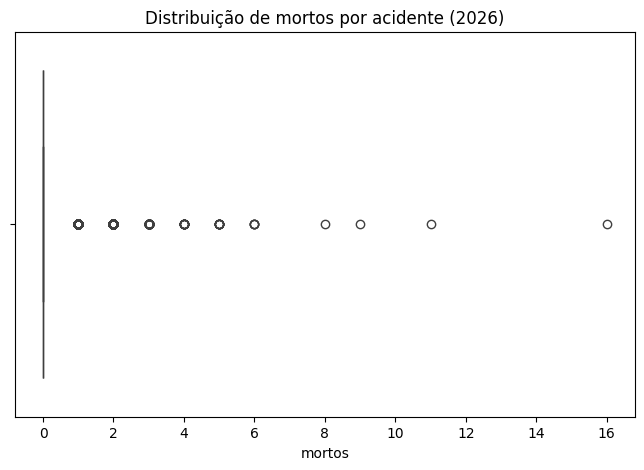

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=tabela['mortos'])
plt.title('Distribuição de mortos por acidente (2026)')
plt.show()


Abaixo a análise de outlier para feridos graves e leves


In [12]:
# --- Outliers em feridos graves (IQR) ---
Q1_fg = tabela['feridos_graves'].quantile(0.25)
Q3_fg = tabela['feridos_graves'].quantile(0.75)
IQR_fg = Q3_fg - Q1_fg

outliers_fg = tabela[(tabela['feridos_graves'] < Q1_fg - 1.5*IQR_fg) | (tabela['feridos_graves'] > Q3_fg + 1.5*IQR_fg)]
print("Outliers em feridos graves:\n", outliers_fg[['data_inversa','uf','municipio','tipo_acidente','feridos_graves']])


Outliers em feridos graves:
       data_inversa  uf                municipio                 tipo_acidente  \
1       2026-01-01  MG                RIO CASCA               Colisão frontal   
4       2026-01-01  MT                   MATUPA               Colisão frontal   
9       2026-01-01  ES  VENDA NOVA DO IMIGRANTE            Colisão com objeto   
14      2026-01-01  ES                 LINHARES     Atropelamento de Pedestre   
17      2026-01-01  PR    CAMPINA GRANDE DO SUL     Saída de leito carroçável   
...            ...  ..                      ...                           ...   
42290   2026-07-09  RJ           ANGRA DOS REIS  Queda de ocupante de veículo   
42303   2026-07-20  RJ                 ITABORAI              Colisão traseira   
42304   2026-07-17  SP                  UBATUBA           Colisão transversal   
42315   2026-06-23  SC                 CAMBORIU           Colisão transversal   
42318   2026-07-28  DF                 BRASILIA     Saída de leito carroçável   

In [13]:
# --- Outliers em feridos leves (IQR) ---
Q1_fl = tabela['feridos_leves'].quantile(0.25)
Q3_fl = tabela['feridos_leves'].quantile(0.75)
IQR_fl = Q3_fl - Q1_fl

outliers_fl = tabela[(tabela['feridos_leves'] < Q1_fl - 1.5*IQR_fl) | (tabela['feridos_leves'] > Q3_fl + 1.5*IQR_fl)]
print("Outliers em feridos leves:\n", outliers_fl[['data_inversa','uf','municipio','tipo_acidente','feridos_leves']])


Outliers em feridos leves:
       data_inversa  uf                  municipio  \
32      2026-01-02  MG               ANTONIO DIAS   
34      2026-01-02  RS                    PELOTAS   
36      2026-01-02  CE                       JATI   
43      2026-01-02  PR                      IRATI   
60      2026-01-03  PE               ABREU E LIMA   
...            ...  ..                        ...   
42208   2026-07-18  SC                    LONTRAS   
42213   2026-07-30  AL                      BELEM   
42245   2026-07-10  BA              SANTO ESTEVAO   
42280   2026-05-21  RS  SANTO ANTONIO DA PATRULHA   
42307   2026-06-04  SE               AREIA BRANCA   

                        tipo_acidente  feridos_leves  
32                    Colisão frontal              5  
34                    Colisão frontal              7  
36     Colisão lateral sentido oposto              3  
43     Colisão lateral sentido oposto              4  
60                   Colisão traseira              3  
...  

Feridos graves: normalmente poucos por acidente (0–2). Casos com 5, 10 ou mais feridos graves devem aparecer como outliers relevantes.

Feridos leves: há maior variação, então acidentes com dezenas de feridos leves podem ser destacados como outliers.

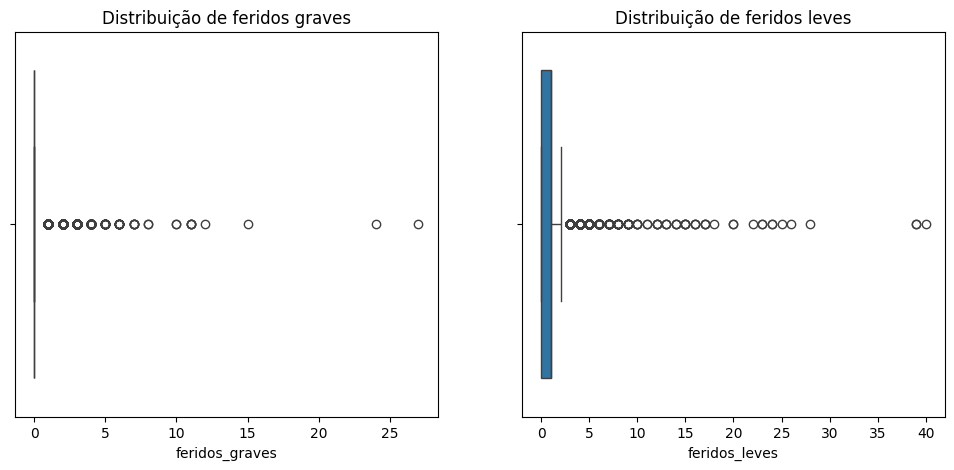

In [14]:


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=tabela['feridos_graves'])
plt.title('Distribuição de feridos graves')

plt.subplot(1,2,2)
sns.boxplot(x=tabela['feridos_leves'])
plt.title('Distribuição de feridos leves')

plt.show()
